# JJA climcal1 ICON CH1 availability

In [ ]:
import arraylake
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## Open store

In [ ]:
client = arraylake.Client()
repo = client.get_repo("martibosch/meteoswiss-unibe-icon-ch1-eps-fc")
session = repo.readonly_session(branch="main")
ds = xr.open_zarr(session.store, zarr_format=3)
ds

  2026-03-25T16:02:25.002712Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773674412996/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121



<xarray.Dataset> Size: 63GB
Dimensions:      (time: 368, lead_time: 34, y_1: 295, x_1: 429)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2025-07-16 ... 2025-08-31T21:00:00
  * lead_time    (lead_time) timedelta64[s] 272B 00:00:00 ... 1 days 09:00:00
  * y_1          (y_1) float64 2kB 1.04e+06 1.042e+06 ... 1.334e+06 1.334e+06
  * x_1          (x_1) float64 3kB 2.439e+06 2.44e+06 ... 2.866e+06 2.867e+06
    lat_1        (y_1, x_1) float64 1MB ...
    lon_1        (y_1, x_1) float64 1MB ...
Data variables:
    TD_2M        (time, lead_time, y_1, x_1) float64 13GB ...
    U_10M        (time, lead_time, y_1, x_1) float64 13GB ...
    V_10M        (time, lead_time, y_1, x_1) float64 13GB ...
    tot_prec_1h  (time, lead_time, y_1, x_1) float64 13GB ...
    T_2M         (time, lead_time, y_1, x_1) float64 13GB ...

## Time axis sanity check

Confirms encoding is correct: step must be exactly 3 h and all values must lie within JJA 2025.

In [ ]:
time = ds.time.values

jja_start = np.datetime64("2025-06-01T00", "ns")
jja_end = np.datetime64("2025-08-31T21", "ns")
step = time[1] - time[0]

print(f"n         : {len(time)}")
print(f"first     : {time[0]}")
print(f"last      : {time[-1]}")
print(
    "step 0→1  : "
    f"{step}  {'✓' if step == np.timedelta64(3, 'h') else '✗ encoding bug!'}"
)
print(f"all in JJA: {bool((time >= jja_start).all() and (time <= jja_end).all())}")

n         : 368
first     : 2025-07-16T00:00:00.000000000
last      : 2025-08-31T21:00:00.000000000
step 0→1  : 10800000000000 nanoseconds  ✓
all in JJA: True


## Coverage summary

In [ ]:
archive_start = time[0]  # first init time available on the SSH server

# Expected grids
expected_jja = np.arange(
    jja_start, jja_end + np.timedelta64(1, "ns"), np.timedelta64(3, "h")
)
expected_archive = np.arange(
    archive_start, jja_end + np.timedelta64(1, "ns"), np.timedelta64(3, "h")
)
pre_archive = np.arange(jja_start, archive_start, np.timedelta64(3, "h"))

present = np.intersect1d(expected_archive, time)
missing = np.setdiff1d(expected_archive, time)
extra = np.setdiff1d(time, expected_archive)

print(
    "Archive gap  "
    f"{str(jja_start)[:13]} – {str(archive_start - np.timedelta64(3, 'h'))[:13]}"
)
print(f"             {len(pre_archive)} init times not available on SSH server")
print()
print(f"Archive period  {str(archive_start)[:13]} – {str(jja_end)[:13]}")
print(f"  Expected : {len(expected_archive):4d}")
print(
    "  Present  : "
    f"{len(present):4d}  ({100 * len(present) / len(expected_archive):.1f}%)"
)
print(
    "  Missing  : "
    f"{len(missing):4d}  ({100 * len(missing) / len(expected_archive):.1f}%)"
)
if len(extra):
    print(f"\nWARNING: {len(extra)} stored value(s) outside expected archive range:")
    for t in extra:
        print(f"  {t}")

Archive gap  2025-06-01T00 – 2025-07-15T21
             360 init times not available on SSH server

Archive period  2025-07-16T00 – 2025-08-31T21
  Expected :  376
  Present  :  368  (97.9%)
  Missing  :    8  (2.1%)


## Availability heatmap

Each cell is one (date, init-hour) combination. Green = present, red = missing.

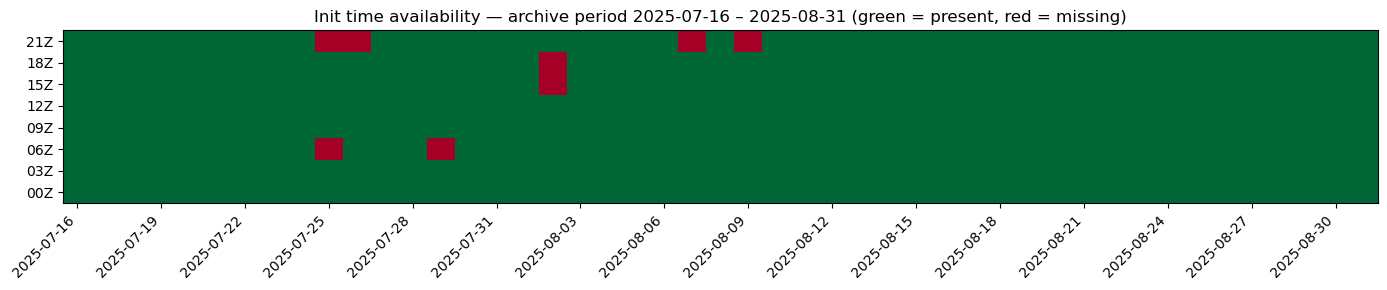

In [ ]:
unique_dates = np.unique(expected_archive.astype("datetime64[D]"))
unique_hours = np.array([0, 3, 6, 9, 12, 15, 18, 21])

# Build grid of shape (n_hours, n_dates) using np.isin — avoids type mismatches
# from mixing datetime64 units via .item()/.tolist().
grid_times = unique_dates[np.newaxis, :].astype("datetime64[ns]") + (
    unique_hours[:, np.newaxis] * np.timedelta64(1, "h")
)  # shape (8, n_dates)
grid = np.isin(grid_times, present).astype(float)

tick_every = max(1, len(unique_dates) // 15)
tick_labels = [
    str(unique_dates[i])[:10] for i in range(0, len(unique_dates), tick_every)
]

fig, ax = plt.subplots(figsize=(14, 3))
ax.imshow(
    grid,
    aspect="auto",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    origin="lower",
    interpolation="none",
)
ax.set_yticks(range(len(unique_hours)))
ax.set_yticklabels([f"{h:02d}Z" for h in unique_hours])
ax.set_xticks(range(0, len(unique_dates), tick_every))
ax.set_xticklabels(tick_labels, rotation=45, ha="right")
ax.set_title(
    f"Init time availability — archive period "
    f"{str(archive_start)[:10]} – {str(jja_end)[:10]} "
    f"(green = present, red = missing)"
)
plt.tight_layout()
plt.show()

## Daily availability

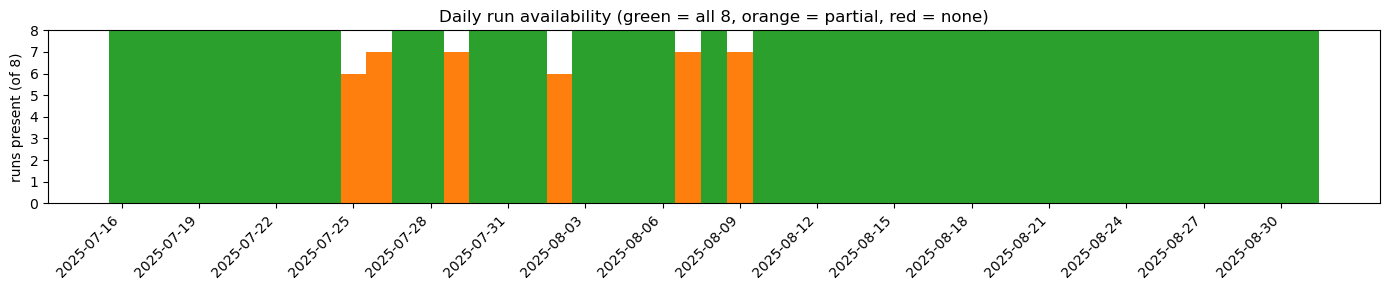

Full days (all 8 runs) : 41
Partial days           : 6
Empty days (no runs)   : 0


In [ ]:
daily_counts = grid.sum(axis=0)
colors = [
    "tab:green" if c == 8 else "tab:orange" if c > 0 else "tab:red"
    for c in daily_counts
]

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(
    range(len(unique_dates)), daily_counts, color=colors, width=1.0, edgecolor="none"
)
ax.axhline(8, color="gray", linewidth=0.5, linestyle="--")
ax.set_ylim(0, 8)
ax.set_yticks(range(9))
ax.set_ylabel("runs present (of 8)")
ax.set_xticks(range(0, len(unique_dates), tick_every))
ax.set_xticklabels(tick_labels, rotation=45, ha="right")
ax.set_title("Daily run availability (green = all 8, orange = partial, red = none)")
plt.tight_layout()
plt.show()

n_full = (daily_counts == 8).sum()
n_partial = ((daily_counts > 0) & (daily_counts < 8)).sum()
n_none = (daily_counts == 0).sum()
print(f"Full days (all 8 runs) : {n_full}")
print(f"Partial days           : {n_partial}")
print(f"Empty days (no runs)   : {n_none}")

## Missing init times

In [ ]:
for t in missing:
    print(t)

2025-07-25T06:00:00.000000000
2025-07-25T21:00:00.000000000
2025-07-26T21:00:00.000000000
2025-07-29T06:00:00.000000000
2025-08-02T15:00:00.000000000
2025-08-02T18:00:00.000000000
2025-08-07T21:00:00.000000000
2025-08-09T21:00:00.000000000


## Gaps in the stored time axis

Checks for unexpected gaps in the stored `time` coordinate (steps larger than 3 h).

In [ ]:
expected_step = np.timedelta64(3, "h")
steps = np.diff(time)
bad = np.where(steps != expected_step)[0]

if len(bad) == 0:
    print("No gaps — all steps are exactly 3 h.")
else:
    print(f"{len(bad)} irregular step(s):")
    for i in bad:
        print(f"  [{i}] {time[i]} → {time[i + 1]}  (step = {steps[i]})")

7 irregular step(s):
  [73] 2025-07-25T03:00:00.000000000 → 2025-07-25T09:00:00.000000000  (step = 21600000000000 nanoseconds)
  [77] 2025-07-25T18:00:00.000000000 → 2025-07-26T00:00:00.000000000  (step = 21600000000000 nanoseconds)
  [84] 2025-07-26T18:00:00.000000000 → 2025-07-27T00:00:00.000000000  (step = 21600000000000 nanoseconds)
  [102] 2025-07-29T03:00:00.000000000 → 2025-07-29T09:00:00.000000000  (step = 21600000000000 nanoseconds)
  [136] 2025-08-02T12:00:00.000000000 → 2025-08-02T21:00:00.000000000  (step = 32400000000000 nanoseconds)
  [176] 2025-08-07T18:00:00.000000000 → 2025-08-08T00:00:00.000000000  (step = 21600000000000 nanoseconds)
  [191] 2025-08-09T18:00:00.000000000 → 2025-08-10T00:00:00.000000000  (step = 21600000000000 nanoseconds)
